[[0.0 1.0 1.0 ... 0.0 32.0 5.0]
 [1.0 0.0 0.0 ... 0.0 28.0 3.0]
 [0.0 1.0 0.0 ... 0.0 45.0 15.0]
 ...
 [1.0 0.0 1.0 ... 0.0 29.0 2.0]
 [0.0 1.0 1.0 ... 0.0 34.0 7.0]
 [1.0 0.0 0.0 ... 0.0 44.0 15.0]]
[179926.92652645  99014.90352108 119093.0796918  100000.
 130625.97011081 144230.0770327  139985.26946597 119342.03166444
  43868.50937573  98210.40605721 134732.45335712 137196.21957328
  58495.60894099  87462.01684803 116806.16328055  43868.50937573
  76789.00218188  64862.77180832  96211.99419656  92944.18639386
 118856.54179437 111995.38296941 134622.93383723  50278.18724471
 100000.          58235.34647052 164006.94511577  41520.32066617
 110215.74819173 155157.59832844  63761.82860434 111818.33985086
  69547.74622928 143124.1266059  109491.13257899  29941.95322963
 169914.48950332  68404.28802365 149301.75833244  52744.49436741
  46660.84545507  91730.64754057 144247.22216646 177640.01011519
  63449.94848232 139748.73156854 106611.11487308  65434.50091114
  48856.54179437  62618.3703

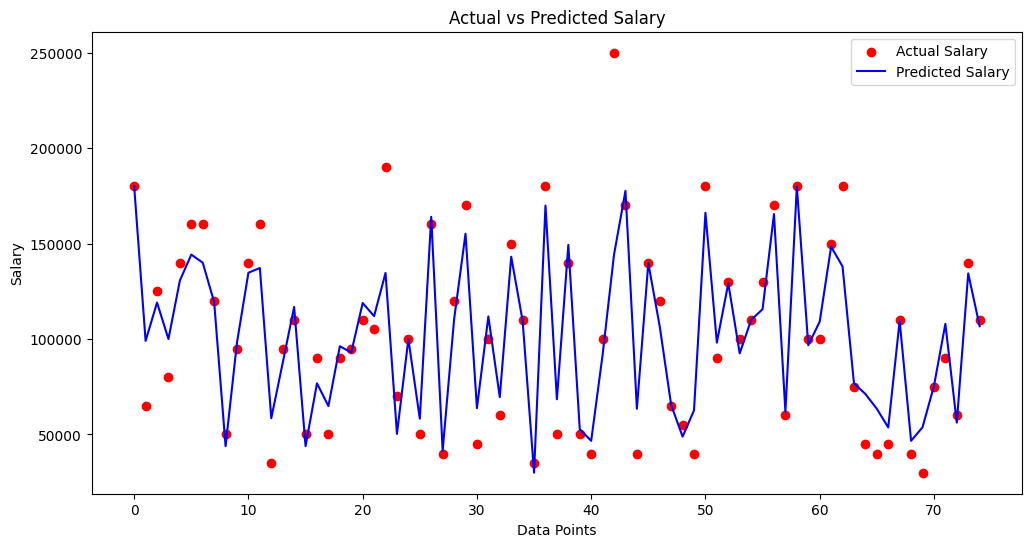

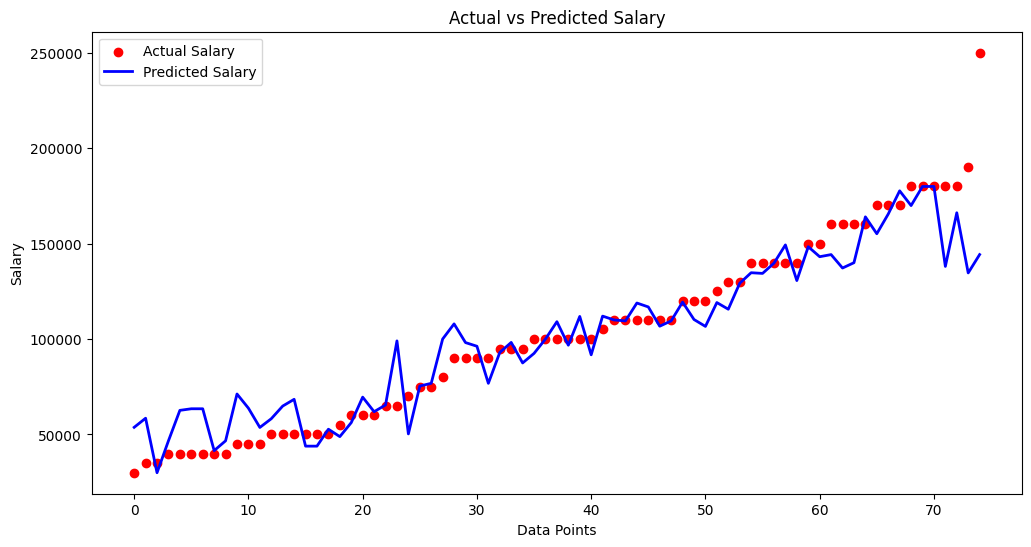

R2 Score: 0.8522475952130885


In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score

data = pd.read_csv('Salary Data.csv')
# print(data.columns)
# print("/////isnull///////")
# print(data.isnull().sum())
# print("/////DESCRIBE///////")
# print(data.describe())
# print("/////INFO///////")
# print(data.info())

data = data.dropna()
# print("/////isnull///////")
# print(data.isnull().sum())

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
# print('///////////////////////////')
# print(X)
# print('///////////////////////////')
# print(y)
# Age,Gender,Education Level,Job Title,Years of Experience,Salary

ct = ColumnTransformer(transformers=[
        ('encoder', OneHotEncoder(sparse_output=False), [1, 2, 3])
    ],
    remainder='passthrough'
)

X = np.array(ct.fit_transform(X))

print(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred)

plt.figure(figsize=(12,6))

# Actual values as scatter
plt.scatter(
    range(len(y_test)),
    y_test,
    color='red',
    label='Actual Salary'
)

# Predicted values as line
plt.plot(
    range(len(y_pred)),
    y_pred,
    color='blue',
    label='Predicted Salary'
)

plt.xlabel("Data Points")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")

plt.legend()

plt.show()

plt.figure(figsize=(12,6))

# Sort test values
sorted_indices = y_test.argsort()

# Actual values
plt.scatter(
    range(len(y_test)),
    y_test[sorted_indices],
    color='red',
    label='Actual Salary'
)

# Predicted values
plt.plot(
    range(len(y_pred)),
    y_pred[sorted_indices],
    color='blue',
    linewidth=2,
    label='Predicted Salary'
)

plt.xlabel("Data Points")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")

plt.legend()

plt.show()

score = r2_score(y_test, y_pred)

print("R2 Score:", score)